In [1]:
import torch # pytorch kutuphanesi, tensor islemleri
import torch.nn as nn # yapay sinir agi katmanlarini tanimlamak icin kullan
import torch.optim as optim # sinir agi agirlik degerlerini guncellemek icin kullanilir
import torchvision # goruntu isleme ve pre-defined(daha once olusturulmus) modelleri icerir
import torchvision.transforms as transforms # goruntu donusumleri yapmak
import matplotlib.pyplot as plt # goruntuleri gorsellestirmek icin kullanilir
import torch
import torchvision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else"cpu")

In [3]:
def get_data_loaders(batch_size=64):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = datasets.EMNIST(
        root="./data",
        split="letters",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.EMNIST(
        root="./data",
        split="letters",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [4]:
train_loader, test_loader = get_data_loaders()

100%|██████████| 562M/562M [01:54<00:00, 4.89MB/s] 


In [5]:
print(len(train_loader.dataset))
print(len(test_loader.dataset))

124800
20800


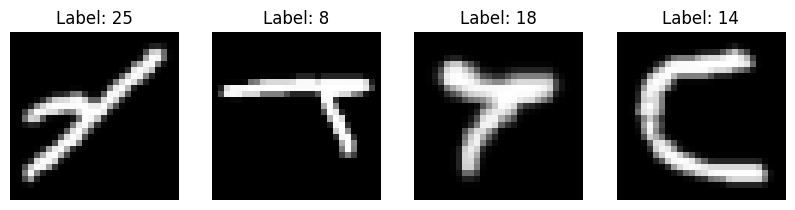

In [7]:
# data visualization
from tkinter import Label

from matplotlib import axes


def visualize_samples(loader, n):
    images, labels = next(iter(loader)) # ilk batch den goruntu ve etiketleri alalim
    fig, axes = plt.subplots(1, n, figsize=(10,5)) # n farkli goruntu icin gorsellestirme alani
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap = "gray") # gorseli gri tonlamali olarak goster
        axes[i].set_title(f"Label: {labels[i].item()}") # goruntuye ait sinif etiketini baslik olarak yaz
        axes[i].axis("off") # eksenleri gizle
    plt.show()

visualize_samples(train_loader, 4)

In [8]:
# %% define ann model
# yapay sinir agi class
class NeuralNetwork(nn.Module): # pytorchun nn.module sinifindan miras alıyorum
    def __init__(self):
        super(NeuralNetwork, self).__init__()

        self.flatten = nn.Flatten() # elimizde bulunan goruntuleri(2D) vektor haline cevirelim(1D) -> 28*28 =784

        self.fc1 = nn.Linear(28*28, 128) # ilk tam bagli katmani olustur: 784 = input size, 128 = output size

        self.relu = nn.ReLU() # aktivasyon fonksiyonu olustur

        self.fc2 = nn.Linear(128, 64) # ikinci tam bagli katmani olustur: 128 = input size, 64 = output size

        self.fc3 = nn.Linear(64, 26) # cikti katmani olustur: 64 = input size, 26 = output (A-Z harfleri)

    def forward(self, x): # forward propagation: ileri yayilim, giris olarak x = goruntu alsin 

        x = self.flatten(x) # initial x = 28*28 lik bir goruntu -> duzlestir 784 vektor haline getir
        x = self.fc1(x) # birinci bagli katman
        x = self.relu(x) # aktivasyon fonksiyonu 
        x = self.fc2(x) # ikinci bagli katman
        x = self.relu(x) # aktivasyon fonksiyonu
        x = self.fc3(x) # output katmani

        return x # modelimizin ciktisini return edelim   
        

# create model and compile

model = NeuralNetwork().to(device)

# kayip fonksiyonu ve optimizasyon algoritmasini belirle
define_loss_and_optimizer = lambda model: (
    nn.CrossEntropyLoss(), # multi class classification problems loss function
    optim.Adam(model.parameters(), lr=0.001)
)

criterion, optimizer = define_loss_and_optimizer(model)

In [14]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):

    model.train()
    train_losses = []

    for epoch in range(epochs):

        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = (labels - 1).to(device)   # EMNIST için düzeltme

            optimizer.zero_grad()

            predictions = model(images)

            loss = criterion(predictions, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.3f}")

    plt.figure()
    plt.plot(range(1, epochs + 1), train_losses, marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.show()

    

Epoch 1/5, Loss: 0.917
Epoch 2/5, Loss: 0.501
Epoch 3/5, Loss: 0.422
Epoch 4/5, Loss: 0.379
Epoch 5/5, Loss: 0.353


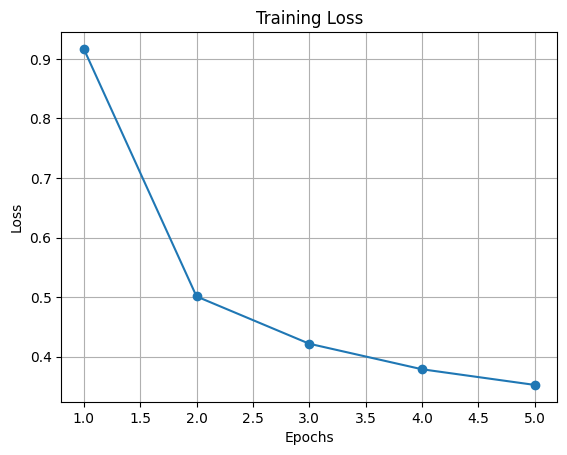

In [15]:
train_model(model, train_loader, criterion, optimizer, epochs=5)

In [18]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = (labels - 1).to(device)   # EMNIST için düzeltme

            predictions = model(images)
            _, predicted = torch.max(predictions, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100*correct/total:.3f}%")


test_model(model, test_loader)

Test Accuracy: 87.918%


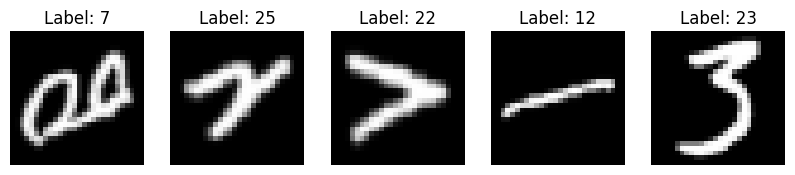

Epoch 1/10, Loss: 0.928
Epoch 2/10, Loss: 0.505
Epoch 3/10, Loss: 0.421
Epoch 4/10, Loss: 0.379
Epoch 5/10, Loss: 0.351
Epoch 6/10, Loss: 0.330
Epoch 7/10, Loss: 0.313
Epoch 8/10, Loss: 0.299
Epoch 9/10, Loss: 0.291
Epoch 10/10, Loss: 0.280


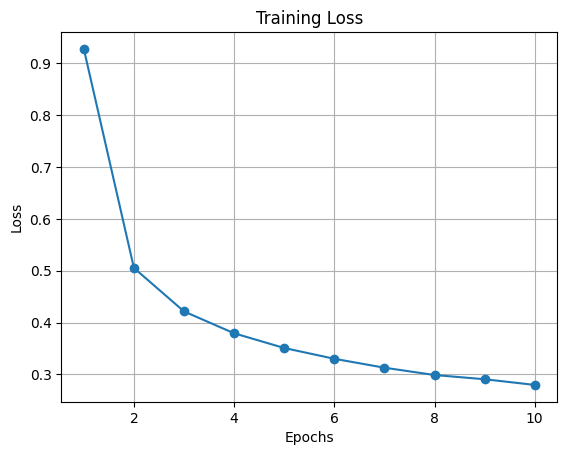

Test Accuracy: 89.255%


In [19]:
# %% main

if __name__ == "__main__":
    train_loader, test_loader = get_data_loaders() # veri yükleyicilerini al
    visualize_samples(train_loader, 5)
    model = NeuralNetwork().to(device)
    criterion, optimizer = define_loss_and_optimizer(model)
    train_model(model, train_loader, criterion, optimizer)
    test_model(model, test_loader)